# Import Libraries

In [1]:
import copy
import os
import random
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import cv2

from PIL import Image, ImageEnhance, ImageFilter
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, accuracy_score
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm

# Dataset Creation Functions

In [2]:
class RetinopathyDataset(Dataset):
    def __init__(self, ann_file, image_dir, transform=None, mode='single', test=False):
        self.ann_file = ann_file
        self.image_dir = image_dir
        self.transform = transform

        self.test = test
        self.mode = mode

        if self.mode == 'single':
            self.data = self.load_data()
        else:
            self.data = self.load_dual_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        if self.mode == 'single':
            return self.get_item(index)
        else:
            return self.get_item_dual(index)

    # 1. single image
    def load_data(self):
        df = pd.read_csv(self.ann_file)

        data = []
        for _, row in df.iterrows():
            file_info = dict()
            file_info['img_path'] = os.path.join(self.image_dir, row['img_path'])
            if not self.test:
                file_info['dr_level'] = int(row['patient_DR_Level'])
            data.append(file_info)
        return data

    def get_item(self, index):
        data = self.data[index]
        img = Image.open(data['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)

        if not self.test:
            label = torch.tensor(data['dr_level'], dtype=torch.int64)
            return img, label
        else:
            return img

    # 2. dual image
    def load_dual_data(self):
        df = pd.read_csv(self.ann_file)

        df['prefix'] = df['image_id'].str.split('_').str[0]  # The patient id of each image
        df['suffix'] = df['image_id'].str.split('_').str[1].str[0]  # The left or right eye
        grouped = df.groupby(['prefix', 'suffix'])

        data = []
        for (prefix, suffix), group in grouped:
            file_info = dict()
            file_info['img_path1'] = os.path.join(self.image_dir, group.iloc[0]['img_path'])
            file_info['img_path2'] = os.path.join(self.image_dir, group.iloc[1]['img_path'])
            if not self.test:
                file_info['dr_level'] = int(group.iloc[0]['patient_DR_Level'])
            data.append(file_info)
        return data

    def get_item_dual(self, index):
        data = self.data[index]
        img1 = Image.open(data['img_path1']).convert('RGB')
        img2 = Image.open(data['img_path2']).convert('RGB')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        if not self.test:
            label = torch.tensor(data['dr_level'], dtype=torch.int64)
            return [img1, img2], label
        else:
            return [img1, img2]

# Augmentation Functions

In [3]:
class CutOut(object):
    def __init__(self, mask_size, p=0.5):
        self.mask_size = mask_size
        self.p = p

    def __call__(self, img):
        if np.random.rand() > self.p:
            return img

        # Ensure the image is a tensor
        if not isinstance(img, torch.Tensor):
            raise TypeError('Input image must be a torch.Tensor')

        # Get height and width of the image
        h, w = img.shape[1], img.shape[2]
        mask_size_half = self.mask_size // 2
        offset = 1 if self.mask_size % 2 == 0 else 0

        cx = np.random.randint(mask_size_half, w + offset - mask_size_half)
        cy = np.random.randint(mask_size_half, h + offset - mask_size_half)

        xmin, xmax = cx - mask_size_half, cx + mask_size_half + offset
        ymin, ymax = cy - mask_size_half, cy + mask_size_half + offset
        xmin, xmax = max(0, xmin), min(w, xmax)
        ymin, ymax = max(0, ymin), min(h, ymax)

        img[:, ymin:ymax, xmin:xmax] = 0
        return img
    
class SLORandomPad:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        pad_width = max(0, self.size[0] - img.width)
        pad_height = max(0, self.size[1] - img.height)
        pad_left = random.randint(0, pad_width)
        pad_top = random.randint(0, pad_height)
        pad_right = pad_width - pad_left
        pad_bottom = pad_height - pad_top
        return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom))


class FundRandomRotate:
    def __init__(self, prob, degree):
        self.prob = prob
        self.degree = degree

    def __call__(self, img):
        if random.random() < self.prob:
            angle = random.uniform(-self.degree, self.degree)
            return transforms.functional.rotate(img, angle)
        return img

In [4]:
def ben_graham_preprocessing(image):
    image = np.array(image)
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), 10), -4, 128)
    return Image.fromarray(image)

def circle_crop(image):
    image = np.array(image)
    height, width, _ = image.shape
    x = int(width / 2)
    y = int(height / 2)
    r = np.amin((x, y))
    circle_image = np.zeros((height, width), np.uint8)
    cv2.circle(circle_image, (x, y), int(r), 1, thickness=-1)
    image = cv2.bitwise_and(image, image, mask=circle_image)
    return Image.fromarray(image)

def clahe(image):
    image = np.array(image.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)
    return Image.fromarray(image).convert('RGB')

def add_gaussian_blur(image):
    return image.filter(ImageFilter.GaussianBlur(radius=2))

def sharpen_image(image):
    enhancer = ImageEnhance.Sharpness(image)
    return enhancer.enhance(2.0)

# Training and Evaluation Functions

In [5]:
def train_model(model, train_loader, val_loader, device, criterion, optimizer, lr_scheduler, num_epochs=25,
                checkpoint_path='model.pth'):
    best_model = model.state_dict()
    best_epoch = None
    best_val_kappa = -1.0  # Initialize the best kappa score

    # Initialize metrics
    training_loss = []
    validation_loss = []
    training_accuracy = []
    validation_accuracy = []
    train_kappa = []
    val_kappa_list = []

    for epoch in range(1, num_epochs + 1):
        print(f'\nEpoch {epoch}/{num_epochs}')
        running_loss = []
        all_preds = []
        all_labels = []

        model.train()

        with tqdm(total=len(train_loader), desc=f'Training', unit=' batch', file=sys.stdout) as pbar:
            for images, labels in train_loader:
                if not isinstance(images, list):
                    images = images.to(device)  # single image case
                else:
                    images = [x.to(device) for x in images]  # dual images case

                labels = labels.to(device)

                optimizer.zero_grad()

                outputs = model(images)
                loss = criterion(outputs, labels.long())

                loss.backward()
                optimizer.step()

                preds = torch.argmax(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                running_loss.append(loss.item())

                pbar.set_postfix({'lr': f'{optimizer.param_groups[0]["lr"]:.1e}', 'Loss': f'{loss.item():.4f}'})
                pbar.update(1)

        lr_scheduler.step()

        epoch_loss = sum(running_loss) / len(running_loss)

        train_metrics = compute_metrics(all_preds, all_labels, per_class=True)
        kappa, accuracy, precision, recall = train_metrics[:4]

        print(f'[Train] Kappa: {kappa:.4f} Accuracy: {accuracy:.4f} '
              f'Precision: {precision:.4f} Recall: {recall:.4f} Loss: {epoch_loss:.4f}')

        if len(train_metrics) > 4:
            precision_per_class, recall_per_class = train_metrics[4:]
            for i, (precision, recall) in enumerate(zip(precision_per_class, recall_per_class)):
                print(f'[Train] Class {i}: Precision: {precision:.4f}, Recall: {recall:.4f}')

        # Evaluation on the validation set at the end of each epoch
        val_metrics, val_loss= evaluate_model(criterion, model, val_loader, device)
        val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
        print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model = model.state_dict()
            torch.save(best_model, checkpoint_path)
        
        training_loss.append(epoch_loss)
        validation_loss.append(val_loss)
        training_accuracy.append(accuracy)
        validation_accuracy.append(val_accuracy)
        train_kappa.append(kappa)
        val_kappa_list.append(val_kappa)

    print(f'[Val] Best kappa: {best_val_kappa:.4f}, Epoch {best_epoch}')

    return model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list



In [6]:
def evaluate_model(criterion, model, test_loader, device, test_only=False, prediction_path='./test_predictions.csv'):
    model.eval()

    all_preds = []
    all_labels = []
    all_image_ids = []

    with tqdm(total=len(test_loader), desc=f'Evaluating', unit=' batch', file=sys.stdout) as pbar:
        for i, data in enumerate(test_loader):

            if test_only:
                images = data
            else:
                images, labels = data

            if not isinstance(images, list):
                images = images.to(device)  # single image case
            else:
                images = [x.to(device) for x in images]  # dual images case

            with torch.no_grad():
                outputs = model(images)
                preds = torch.argmax(outputs, 1)
            if not test_only:
                val_loss = criterion(outputs, labels.to(device).long())
                val_loss = val_loss.cpu().numpy()

            if not isinstance(images, list):
                # single image case
                all_preds.extend(preds.cpu().numpy())
                image_ids = [
                    os.path.basename(test_loader.dataset.data[idx]['img_path']) for idx in
                    range(i * test_loader.batch_size, i * test_loader.batch_size + len(images))
                ]
                all_image_ids.extend(image_ids)
                if not test_only:
                    all_labels.extend(labels.numpy())
            else:
                # dual images case
                for k in range(2):
                    all_preds.extend(preds.cpu().numpy())
                    image_ids = [
                        os.path.basename(test_loader.dataset.data[idx][f'img_path{k + 1}']) for idx in
                        range(i * test_loader.batch_size, i * test_loader.batch_size + len(images[k]))
                    ]
                    all_image_ids.extend(image_ids)
                    if not test_only:
                        all_labels.extend(labels.numpy())

            pbar.update(1)

    # Save predictions to csv file for Kaggle online evaluation
    if test_only:
        df = pd.DataFrame({
            'ID': all_image_ids,
            'TARGET': all_preds
        })
        df.to_csv(prediction_path, index=False)
        print(f'[Test] Save predictions to {os.path.abspath(prediction_path)}')
    else:
        metrics = compute_metrics(all_preds, all_labels)
        return metrics, val_loss

In [7]:
def compute_metrics(preds, labels, per_class=False):
    kappa = cohen_kappa_score(labels, preds, weights='quadratic')
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)

    # Calculate and print precision and recall for each class
    if per_class:
        precision_per_class = precision_score(labels, preds, average=None, zero_division=0)
        recall_per_class = recall_score(labels, preds, average=None, zero_division=0)
        return kappa, accuracy, precision, recall, precision_per_class, recall_per_class

    return kappa, accuracy, precision, recall

# Creating Models

In [8]:
class SingleModels(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super().__init__()
        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
        elif model_name == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)
        elif model_name == 'resnet152':
            self.backbone = models.resnet152(pretrained=True)
        elif model_name == 'vgg16':
            self.backbone = models.vgg16(pretrained=True)
        elif model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
        elif model_name == 'densenet121':
            self.backbone = models.densenet121(pretrained=True)

        self.backbone.fc = nn.Identity()  # Remove the original classification layer

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x

In [9]:
class MyDualModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super().__init__()

        if model_name == 'resnet18':
            backbone = models.resnet18(pretrained=True)
        elif model_name == 'resnet34':
            backbone = models.resnet34(pretrained=True)
        elif model_name == 'resnet152':
            backbone = models.resnet152(pretrained=True)
        elif model_name == 'vgg16':
            backbone = models.vgg16(pretrained=True)
        elif model_name == 'efficientnet_b0':
            backbone = models.efficientnet_b0(pretrained=True)
        elif model_name == 'densenet121':
            backbone = models.densenet121(pretrained=True)
        backbone.fc = nn.Identity()

        # Here the two backbones will have the same structure but unshared weights
        self.backbone1 = copy.deepcopy(backbone)
        self.backbone2 = copy.deepcopy(backbone)

        self.fc = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, images):
        image1, image2 = images

        x1 = self.backbone1(image1)
        x2 = self.backbone2(image2)

        x = torch.cat((x1, x2), dim=1)
        x = self.fc(x)
        return x

# Hyper Parameters

In [10]:
# Hyper Parameters
batch_size = 24
num_classes = 5  # 5 DR levels
learning_rate = 0.001
num_epochs = 5

# Transformers

In [11]:
# Transformations
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # Add augmentation here
])
val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [12]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((210, 210)),
    SLORandomPad((224, 224)),
    FundRandomRotate(prob=0.5, degree=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.1, 0.9)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Main Loop

In [13]:
# Choose between 'single image' and 'dual images' pipeline
# This will affect the model definition, dataset pipeline, training and evaluation

mode = 'single'  # forward single image to the model each time
# mode = 'dual'  # forward two images of the same eye to the model and fuse the features

assert mode in ('single', 'dual')

In [14]:
model_name = 'resnet18' # s:0.7805
model_name = 'resnet34' # s:0.7814

model_name = 'vgg11'
model_name = 'vgg13'
model_name = 'vgg16'
model_name = 'vgg19'

model_name = 'efficientnet_b0'
model_name = 'efficientnet_b1'
model_name = 'efficientnet_b2'
model_name = 'efficientnet_b3'
model_name = 'efficientnet_b4'

model_name = 'densenet121'
model_name = 'densenet169'
model_name = 'densenet201'
model_name = 'densenet161'

In [15]:
# Create datasets
train_dataset = RetinopathyDataset('./DeepDRiD/train.csv', './DeepDRiD/train/', transform_train, mode)
val_dataset = RetinopathyDataset('./DeepDRiD/val.csv', './DeepDRiD/val/', transform_test, mode)
test_dataset = RetinopathyDataset('./DeepDRiD/test.csv', './DeepDRiD/test/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
train_df = pd.read_csv('./DeepDRiD/train.csv')
train_left_eye_DR_Level_counts = pd.read_csv('./DeepDRiD/train.csv')['left_eye_DR_Level'].value_counts()
train_right_eye_DR_Level_counts = pd.read_csv('./DeepDRiD/train.csv')['right_eye_DR_Level'].value_counts()
train_left_eye_DR_Level_counts, train_right_eye_DR_Level_counts

(left_eye_DR_Level
 0.0    260
 2.0    124
 3.0     96
 1.0     78
 4.0     42
 Name: count, dtype: int64,
 right_eye_DR_Level
 0.0    280
 3.0    118
 2.0    110
 1.0     62
 4.0     30
 Name: count, dtype: int64)

In [17]:
from sklearn.utils import resample
# Group by patient_id and assign patient_DR_Level to each group
grouped = train_df.groupby('patient_id').agg({
    'patient_DR_Level': 'first',
    'image_id': list,
    'img_path': list
}).reset_index()

# Analyze class distribution
class_counts = grouped['patient_DR_Level'].value_counts()
print("Original class distribution:\n", class_counts)

# Determine the maximum class count
max_count = class_counts.max()

# Oversample underrepresented classes
oversampled_data = []
for label in class_counts.index:
    patients_in_class = grouped[grouped['patient_DR_Level'] == label]
    oversampled = resample(
        patients_in_class,
        replace=True,               # Sample with replacement
        n_samples=max_count,        # Match the max count
        random_state=42             # For reproducibility
    )
    oversampled_data.append(oversampled)

# Combine oversampled data into a single DataFrame
balanced_grouped = pd.concat(oversampled_data)

# Merge back into the original format
balanced_data = train_df.merge(balanced_grouped[['patient_id']], on='patient_id', how='inner')

# Check the new class distribution
new_class_counts = balanced_grouped['patient_DR_Level'].value_counts()
print("Balanced class distribution:\n", new_class_counts)
# Save balanced dataset
balanced_data.to_csv("balanced_data.csv", index=False)

Original class distribution:
 patient_DR_Level
0    90
2    60
1    60
3    60
4    30
Name: count, dtype: int64
Balanced class distribution:
 patient_DR_Level
0    90
2    90
1    90
3    90
4    90
Name: count, dtype: int64


In [18]:
# Create datasets
train_dataset = RetinopathyDataset('balanced_data.csv', './DeepDRiD/train/', transform_train, mode)
val_dataset = RetinopathyDataset('./DeepDRiD/val.csv', './DeepDRiD/val/', transform_test, mode)
test_dataset = RetinopathyDataset('./DeepDRiD/test.csv', './DeepDRiD/test/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [21]:
model_name = 'resnet34'

# Define the model
if mode == 'single':
    model = SingleModels()
else:
    model = MyDualModel()

print(model, '\n')
print('Pipeline Mode:', mode)


# Define the weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Use GPU device is possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./model_1.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./model_1.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions.csv')

c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SingleModels(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

C:\Users\murat\AppData\Local\Temp\ipykernel_17084\3519179169.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./model_1.pth', map_location='cpu'


[Val] Kappa: 0.5894 Accuracy: 0.4325 Precision: 0.4553 Recall: 0.4325
[Val] Best kappa: 0.6829, Epoch 2
Evaluating: 100%|██████████| 17/17 [00:02<00:00,  6.85 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions.csv


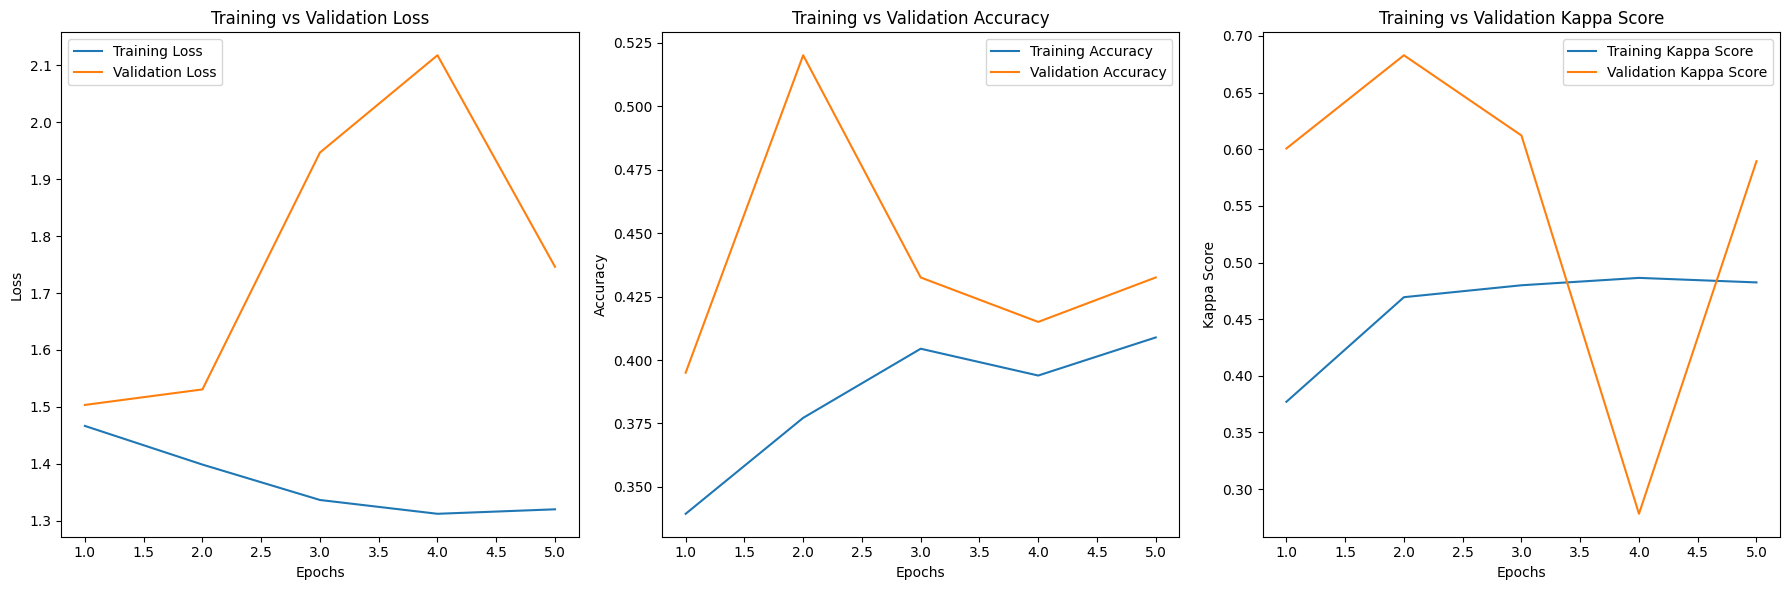

In [23]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()
